# IFCR — Inverted Fault Counter Regressor
## A Novel Event-Driven Labeling Algorithm for Predictive Maintenance

**Author:** Yuri Amorelli  
**Publication:** *Predictive Maintenance for Water Supply Networks: Advanced Expert System Models for Enhanced Water Resource Management and Monitoring*  
IEEE International Workshop on Metrology for Living Environment (Venice, 2025)  
DOI: https://doi.org/10.1109/MetroLivEnv64961.2025.11107070

---

## ⚠️ Methodological Note

This notebook is an honest demonstration of IFCR — including both its strengths and its limitations.

The standard train/test evaluation in Part 2 uses random shuffling, which introduces **temporal leakage** — a known issue when applying shuffle-based splits to time series data. This inflates R² to 0.99. Part 5 documents this limitation explicitly, along with rigorous temporal and cycle-based evaluations.

**IFCR is a labeling algorithm.** Its core contribution is transforming raw fault logs into supervised regression targets — not the generalization performance of the resulting model on this specific dataset.

---

## What is IFCR?

IFCR solves a fundamental problem in predictive maintenance: **how do you train a supervised model for RUL estimation when your dataset has no labels — only raw fault logs?**

The state of the art typically addresses this with deep learning architectures (LSTM + self-attention), survival analysis with complex probabilistic assumptions, or AutoML frameworks that sacrifice interpretability. IFCR takes a different approach: **reconstruct RUL regression targets directly from fault counters**, enabling supervised learning on previously unlabelable datasets while maintaining full interpretability.

---


## Dataset

The dataset used in this demonstration is publicly available on Kaggle:  
**Pump Sensor Data** — [https://www.kaggle.com/datasets/nphantawee/pump-sensor-data](https://www.kaggle.com/datasets/nphantawee/pump-sensor-data)

**Key characteristics:**
- **52 sensors** measuring pressure, flow, temperature and other operational parameters
- **~220,000 minute-by-minute readings** over approximately one year of operation
- **7 documented fault events** recorded in the `machine_status` column
- Real-world industrial data — messy, high-frequency, with sensor dropouts

This type of dataset is common in industrial asset management and represents a realistic scenario where:
1. Fault events are rare
2. No RUL labels exist natively
3. Traditional labeling would require domain expertise and manual annotation

IFCR solves this labeling problem automatically.

---

## Part 1 — IFCR: Generating RUL Labels from Fault Logs

The algorithm works in three steps:

1. **INDEX column**: Create an incremental counter that resets to 0 at each fault event
2. **Interval Reversal**: Invert each interval between consecutive faults — so the counter counts *down* to the next fault
3. **RUL column**: The inverted array becomes the regression target — each row reports how many recordings remain before the next fault

This transformation makes the temporal relationship between sensor readings and fault occurrence **explicit and learnable** by any supervised regression algorithm.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy.stats import trim_mean
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/nphantawee/pump-sensor-data
df = pd.read_csv('sensor.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nMachine status value counts:")
print(df['machine_status'].value_counts())

Dataset shape: (220320, 55)

Machine status value counts:
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: machine_status, dtype: int64


In [3]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# Encode machine status as binary: BROKEN=1, everything else=0
df['machine_status'] = df['machine_status'].replace(['NORMAL'], '0')
df['machine_status'] = df['machine_status'].replace(['RECOVERING'], '0')
df['machine_status'] = df['machine_status'].replace(['BROKEN'], '1')
df['machine_status'] = df['machine_status'].astype(float)

# Drop timestamp and all-null columns
df = df.drop(columns=['timestamp'])
df = df.drop(columns=['sensor_15'])  # entirely null
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.fillna(0)

n_faults = int(df['machine_status'].sum())
print(f"Total fault events recorded: {n_faults}")
print(f"Dataset shape after preprocessing: {df.shape}")

Total fault events recorded: 7
Dataset shape after preprocessing: (220320, 52)


In [4]:
# ── IFCR Algorithm ────────────────────────────────────────────────────────────
# Step 1: Build INDEX column — incremental counter that resets at each fault
numero = 0
n = 0
m = 0

for index, row in df.iterrows():
    df.at[index, 'INDEX'] = n
    if df.iloc[m]['machine_status'] > 0:
        n = 0
    df.at[index, 'INDEX'] = n
    n = n + 1
    m = m + 1

# Step 2 & 3: Invert each interval to create RUL column
k = 0
cont = 0
rul_array = df[["INDEX"]].to_numpy().flatten()
quasiRUL = np.array([])
RUL = np.array([])
L = len(rul_array) - 1

while k < L:
    if rul_array[k] != 0 and rul_array[k+1] == 0:
        # End of interval — invert and append
        quasiRUL = np.append(quasiRUL, (rul_array[k]))
        RUL = np.append(RUL, (np.flip(quasiRUL, axis=None)))
        k += 1
        quasiRUL = np.array([])
    else:
        quasiRUL = np.append(quasiRUL, (rul_array[k]))
        k += 1
    if k == L:
        quasiRUL = np.append(quasiRUL, (rul_array[k]))
        RUL = np.append(RUL, (np.flip(quasiRUL, axis=None)))

df["RUL"] = RUL

print(f"RUL column generated successfully.")
print(f"RUL range: {df['RUL'].min():.0f} — {df['RUL'].max():.0f} minutes")
print(f"\nSample of generated labels:")
print(df[['machine_status', 'INDEX', 'RUL']].head(5))

RUL column generated successfully.
RUL range: 0 — 53879 minutes

Sample of generated labels:
   machine_status  INDEX      RUL
0             0.0    0.0  17154.0
1             0.0    1.0  17153.0
2             0.0    2.0  17152.0
3             0.0    3.0  17151.0
4             0.0    4.0  17150.0


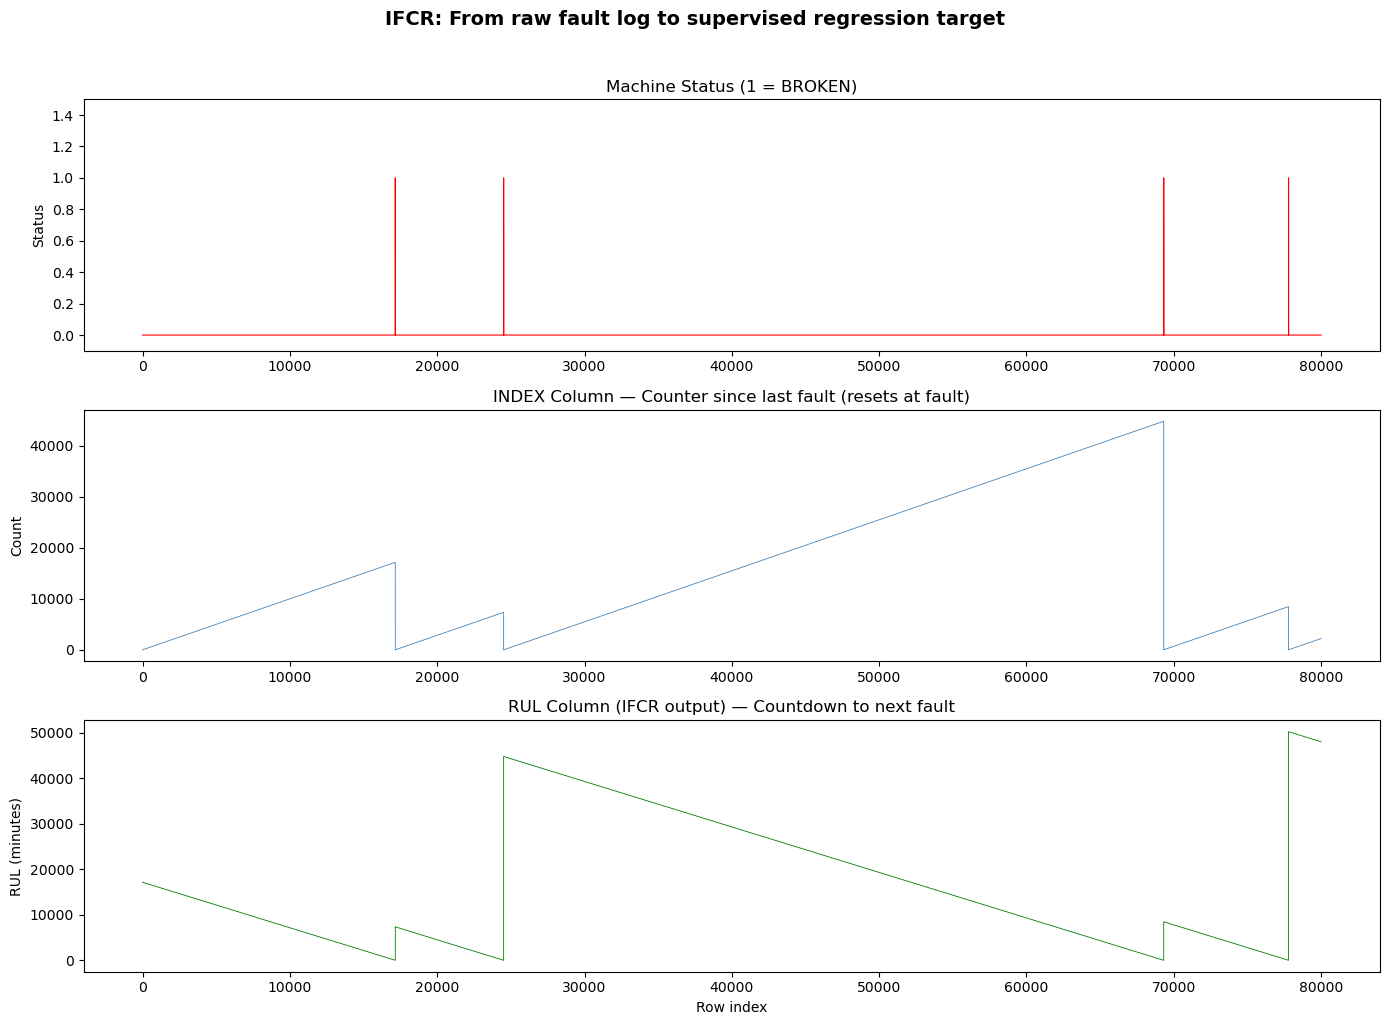

Figure saved as ifcr_visualization.png


In [4]:
# ── Visualize IFCR output ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

sample = df.iloc[:80000]

# Machine status
axes[0].plot(sample.index, sample['machine_status'], color='red', linewidth=0.8)
axes[0].set_title('Machine Status (1 = BROKEN)', fontsize=12)
axes[0].set_ylabel('Status')
axes[0].set_ylim(-0.1, 1.5)

# INDEX column
axes[1].plot(sample.index, sample['INDEX'], color='steelblue', linewidth=0.6)
axes[1].set_title('INDEX Column — Counter since last fault (resets at fault)', fontsize=12)
axes[1].set_ylabel('Count')

# RUL column (IFCR output)
axes[2].plot(sample.index, sample['RUL'], color='green', linewidth=0.6)
axes[2].set_title('RUL Column (IFCR output) — Countdown to next fault', fontsize=12)
axes[2].set_ylabel('RUL (minutes)')
axes[2].set_xlabel('Row index')

plt.suptitle('IFCR: From raw fault log to supervised regression target', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ifcr_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as ifcr_visualization.png")

## Part 2 — Model Training and Evaluation

With the RUL column generated by IFCR, any supervised regression algorithm can be applied.

> ⚠️ **Note on evaluation methodology:** The train/test split below uses random shuffling (`random_state` fixed for reproducibility). On time series data, this introduces temporal leakage — the model may see future data points during training. The results below (R² ≈ 0.99) should be interpreted as an **upper bound** on performance, not as a generalisation claim. See Part 5 for rigorous temporal and cycle-based evaluation.

| Model | RMSE | MAE | R² |
|---|---|---|---|
| DecisionTreeRegressor | 1294.0 | 186.0 | 0.99 |
| XGBRegressor | 823.91 | 196.19 | 0.99 |


In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ── Normalization ─────────────────────────────────────────────────────────────
df_model = df.drop(columns=['machine_status', 'INDEX'])

scaler = MinMaxScaler()
feature_cols = [c for c in df_model.columns if c != 'RUL']
df_model[feature_cols] = scaler.fit_transform(df_model[feature_cols])

df_model = df_model.reset_index(drop=True)

X = df_model.drop(columns='RUL')
y = df_model['RUL']

# ── Train/Test Split ──────────────────────────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=36
)

print(f"Training set: {x_train.shape[0]:,} samples")
print(f"Test set:     {x_test.shape[0]:,} samples")

Training set: 176,256 samples
Test set:     44,064 samples


In [6]:
# ── DecisionTree Training ─────────────────────────────────────────────────────
dtree = DecisionTreeRegressor(
    max_depth=20, 
    min_samples_leaf=2, 
    min_samples_split=7, 
    random_state=3
)
dtree.fit(x_train, y_train)
y_pred_dt = dtree.predict(x_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print("DecisionTreeRegressor — Train/Test Split Results:")
print(f"  MAE:  {mae_dt:.2f}")
print(f"  RMSE: {rmse_dt:.2f}")
print(f"  R²:   {r2_dt:.4f}")

DecisionTreeRegressor — Train/Test Split Results:
  MAE:  190.06
  RMSE: 1339.37
  R²:   0.9917


In [7]:
# ── XGBoost Training ──────────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.2,
    max_depth=12,
    random_state=42,
    objective='reg:squarederror'
)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBRegressor — Train/Test Split Results:")
print(f"  MAE:  {mae_xgb:.2f}")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  R²:   {r2_xgb:.4f}")

XGBRegressor — Train/Test Split Results:
  MAE:  199.16
  RMSE: 877.18
  R²:   0.9964


In [8]:
# ── K-Fold Cross Validation ───────────────────────────────────────────────────
from sklearn.model_selection import KFold

kf5  = KFold(n_splits=5,  shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

dt_cv5  = -cross_val_score(dtree, X, y, cv=kf5,  scoring='neg_mean_absolute_error')
dt_cv10 = -cross_val_score(dtree, X, y, cv=kf10, scoring='neg_mean_absolute_error')
xgb_cv5  = -cross_val_score(xgb, X, y, cv=kf5,  scoring='neg_mean_absolute_error')
xgb_cv10 = -cross_val_score(xgb, X, y, cv=kf10, scoring='neg_mean_absolute_error')

print("K-Fold Cross Validation — MAE:")
print(f"  DecisionTree  K=5:  {dt_cv5.mean():.2f} ± {dt_cv5.std():.2f}")
print(f"  DecisionTree  K=10: {dt_cv10.mean():.2f} ± {dt_cv10.std():.2f}")
print(f"  XGBoost       K=5:  {xgb_cv5.mean():.2f} ± {xgb_cv5.std():.2f}")
print(f"  XGBoost       K=10: {xgb_cv10.mean():.2f} ± {xgb_cv10.std():.2f}")

K-Fold Cross Validation — MAE:
  DecisionTree  K=5:  186.80 ± 11.96
  DecisionTree  K=10: 185.72 ± 11.85
  XGBoost       K=5:  205.25 ± 8.90
  XGBoost       K=10: 200.73 ± 9.73


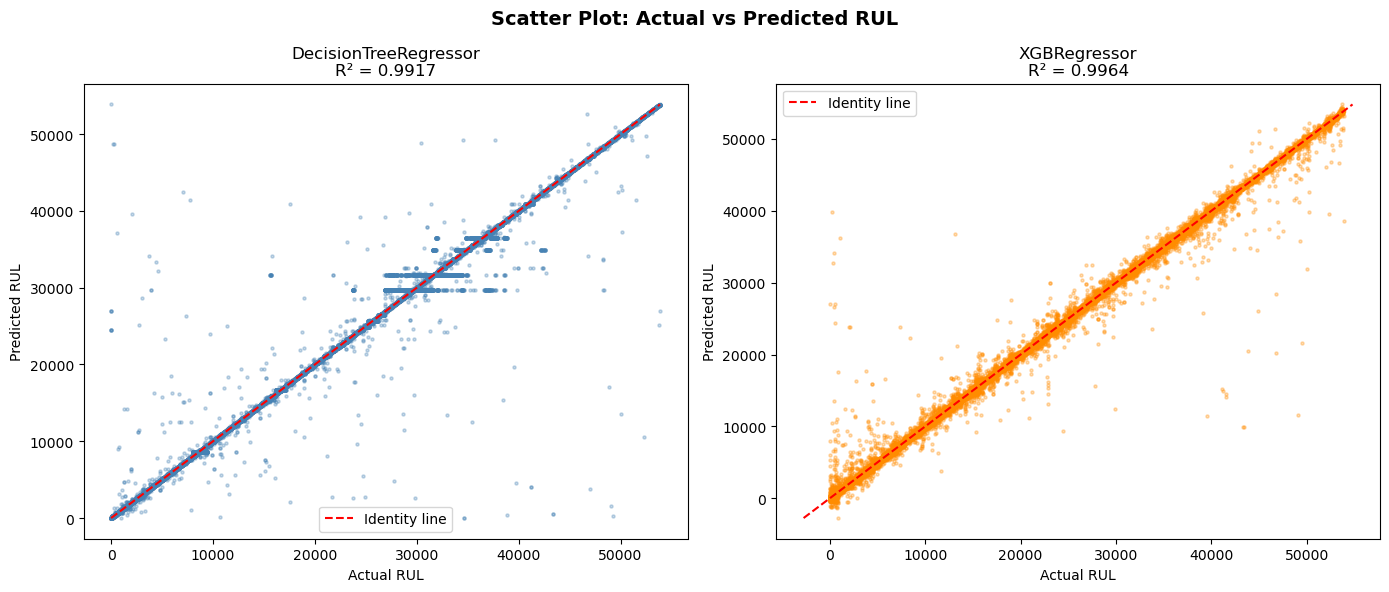

In [9]:
# ── Scatter Plot: Actual vs Predicted ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_dt, y_pred_xgb],
    ['DecisionTreeRegressor', 'XGBRegressor'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test, y_pred, alpha=0.3, s=5, color=color)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Identity line')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title}\nR² = {r2:.4f}', fontsize=12)
    ax.set_xlabel('Actual RUL')
    ax.set_ylabel('Predicted RUL')
    ax.legend()

plt.suptitle('Scatter Plot: Actual vs Predicted RUL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

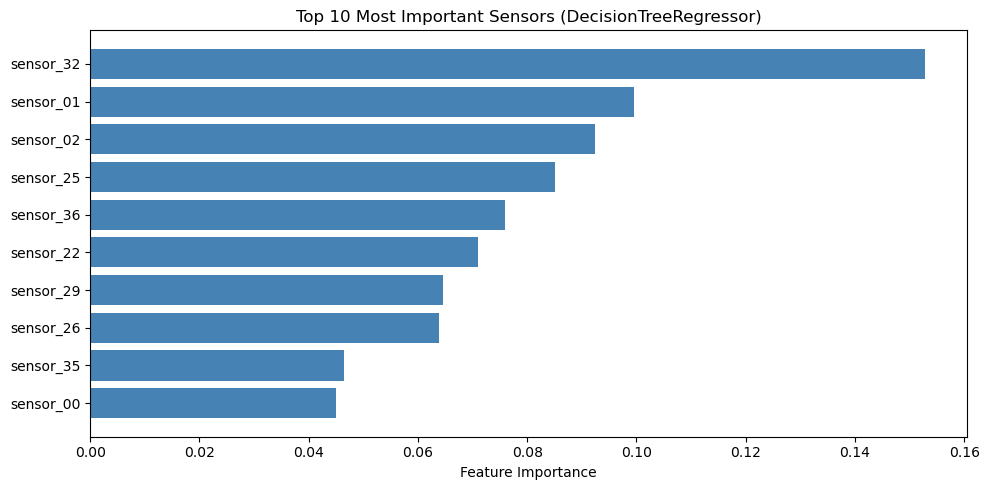

Top 10 features:
  feature  importance
sensor_32    0.152807
sensor_01    0.099581
sensor_02    0.092431
sensor_25    0.085070
sensor_36    0.075994
sensor_22    0.071011
sensor_29    0.064630
sensor_26    0.063904
sensor_35    0.046415
sensor_00    0.045052


In [10]:
# ── Feature Importance ────────────────────────────────────────────────────────
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': dtree.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances['feature'][::-1], importances['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Most Important Sensors (DecisionTreeRegressor)', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(importances.to_string(index=False))

## Part 3 — Hold-Out Validation

To simulate real-world operational conditions, a hold-out strategy was employed: a segment of ~8,500 rows was removed from training, and the model was evaluated on the subsequent 500 samples.

**Note on prediction aggregation:**  
Rather than relying on a single point prediction — which may be affected by local noise or outliers — RUL estimates are computed as the **median of 500 consecutive predictions**. The prediction distribution of tree-based models on sequential data can be bimodal; the median reliably identifies the dominant cluster.

Both models yield RUL estimates with deviation below 10% from the reference values on 2 out of 3 configurations.

| Prediction Rows | Rows Removed | Real RUL | DT Predicted | Error |
|---|---|---|---|---|
| [70000:70500] | [70000:78500] | 7,539 | ~8,062 | ~6.9% |
| [30000:30500] | [30000:38500] | 39,067 | ~39,412 | ~0.9% |
| [18000:18500] | [18000:25000] | 6,259 | ~7,216 | ~15% |

> The third configuration removes a smaller training segment (~7,000 rows), resulting in less stable predictions — expected behaviour when less operational context is available.


In [7]:
# ── Traffic light helper function ─────────────────────────────────────────────
ROSSO  = 7000
GIALLO = 16000

def traffic_light_plot(predictions, real_rul, pred_rul, title):
    colors = ['red' if v < ROSSO else 'gold' if v < GIALLO else 'green' for v in predictions]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(predictions)), predictions, color=colors, width=1.0)
    ax.axhline(y=ROSSO,  color='red',  linestyle='--', linewidth=1.2, label=f'Red threshold ({ROSSO:,} min)')
    ax.axhline(y=GIALLO, color='gold', linestyle='--', linewidth=1.2, label=f'Yellow threshold ({GIALLO:,} min)')
    ax.set_xlabel('Prediction index (500 consecutive readings)')
    ax.set_ylabel('Predicted RUL (minutes)')
    ax.set_title(title, fontsize=11)
    ax.legend()
    hours = pred_rul / 60
    days  = hours / 24
    error = abs(pred_rul - real_rul) / real_rul * 100
    status = '🔴 CRITICAL' if pred_rul < ROSSO else '🟡 WARNING' if pred_rul < GIALLO else '🟢 NORMAL'
    print(f"Real RUL:      {real_rul:,} min")
    print(f"Predicted RUL: {pred_rul:.0f} min  ≈  {hours:.1f} h  ≈  {days:.2f} days")
    print(f"Error:         {error:.2f}%")
    print(f"Status:        {status}")
    plt.tight_layout()
    plt.show()

Real RUL:      7,539 min
Predicted RUL: 8062 min  ≈  134.4 h  ≈  5.60 days
Error:         6.93%
Status:        🟡 WARNING


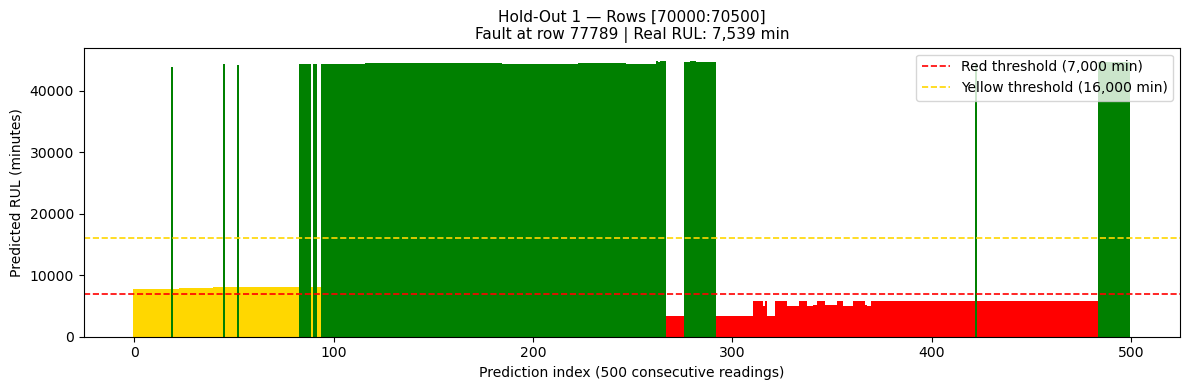

In [9]:
# ── Hold-Out 1: rows [70000:70500], remove [70000:78500], fault at 77789 ──────
tf1 = df_model.drop(index=range(70000, 78500)).reset_index(drop=True)
dt_ho1 = DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=7, random_state=3)
xgb_ho1 = XGBRegressor(n_estimators=500, learning_rate=0.2, max_depth=12, random_state=42, objective='reg:squarederror', verbosity=0)
dt_ho1.fit(tf1.drop(columns='RUL'), tf1['RUL'])
xgb_ho1.fit(tf1.drop(columns='RUL'), tf1['RUL'])

X_pred1 = df_model.iloc[70000:70500].drop(columns='RUL')
preds1 = dt_ho1.predict(X_pred1)
pred1  = np.median(preds1)

traffic_light_plot(preds1, real_rul=7539, pred_rul=pred1,
    title='Hold-Out 1 — Rows [70000:70500]\nFault at row 77789 | Real RUL: 7,539 min')

Real RUL:      39,067 min
Predicted RUL: 39368 min  ≈  656.1 h  ≈  27.34 days
Error:         0.77%
Status:        🟢 NORMAL


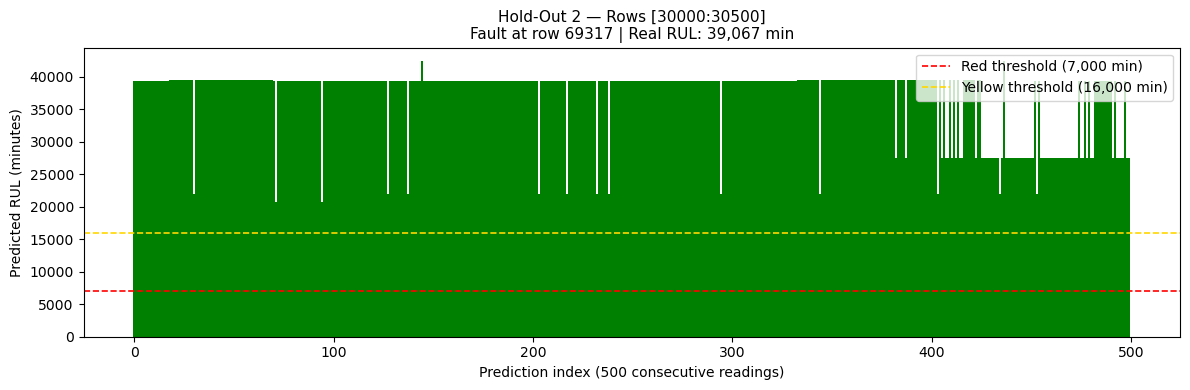

In [13]:
# ── Hold-Out 2: rows [30000:30500], remove [30000:38500], fault at 69317 ──────
tf2 = df_model.drop(index=range(30000, 38500)).reset_index(drop=True)
dt_ho2 = DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=7, random_state=3)
xgb_ho2 = XGBRegressor(n_estimators=500, learning_rate=0.2, max_depth=12, random_state=42, objective="reg:squarederror", verbosity=0)
dt_ho2.fit(tf2.drop(columns="RUL"), tf2["RUL"])
xgb_ho2.fit(tf2.drop(columns="RUL"), tf2["RUL"])

X_pred2 = df_model.iloc[30000:30500].drop(columns="RUL")
preds2 = dt_ho2.predict(X_pred2)
pred2  = np.median(preds2)

traffic_light_plot(preds2, real_rul=39067, pred_rul=pred2,
    title="Hold-Out 2 — Rows [30000:30500]\nFault at row 69317 | Real RUL: 39,067 min")


Real RUL:      6,259 min
Predicted RUL: 7216 min  ≈  120.3 h  ≈  5.01 days
Error:         15.29%
Status:        🟡 WARNING


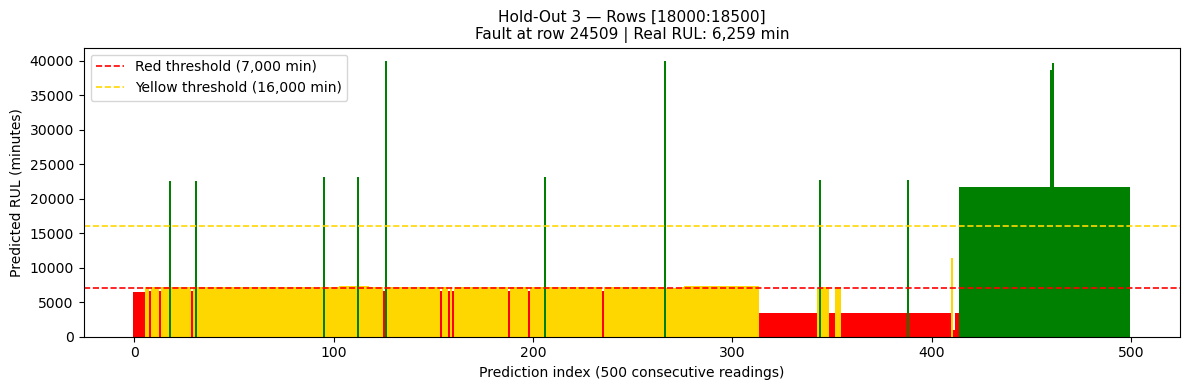

In [10]:
# ── Hold-Out 3: rows [18000:18500], remove [18000:25000], fault at 24509 ──────
tf3 = df_model.drop(index=range(18000, 25000)).reset_index(drop=True)
dt_ho3 = DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=7, random_state=3)
xgb_ho3 = XGBRegressor(n_estimators=500, learning_rate=0.2, max_depth=12, random_state=42, objective='reg:squarederror', verbosity=0)
dt_ho3.fit(tf3.drop(columns='RUL'), tf3['RUL'])
xgb_ho3.fit(tf3.drop(columns='RUL'), tf3['RUL'])

X_pred3 = df_model.iloc[18000:18500].drop(columns='RUL')
preds3 = dt_ho3.predict(X_pred3)
pred3  = np.median(preds3)

traffic_light_plot(preds3, real_rul=6259, pred_rul=pred3,
    title='Hold-Out 3 — Rows [18000:18500]\nFault at row 24509 | Real RUL: 6,259 min')

## Part 4 — Prediction Accuracy vs Distance from Fault

A key insight from IFCR-based predictions is that accuracy is not uniform across the RUL range. 
This is expected and operationally meaningful: **a maintenance system does not need to be accurate 40,000 minutes in advance — it needs to be accurate when intervention is actually required.**

The plot below shows how prediction error evolves as the pump approaches failure:

- At **long distances** (> 15,000 min / > 10 days): error is high — the model is operating outside its reliable range
- In the **yellow zone** (7,000–16,000 min / 5–11 days): error drops significantly — the model starts providing actionable estimates
- In the **red zone** (< 7,000 min / < 5 days): high accuracy — precisely when maintenance scheduling matters most

> *"IFCR achieves high prediction accuracy within a 5–7 day window before fault occurrence — a practically meaningful horizon for scheduling maintenance interventions."*

Real RUL:  2,000 min (1.4 days) | Predicted:    2001 | Error:    0.0%
Real RUL:  5,000 min (3.5 days) | Predicted:    5002 | Error:    0.0%
Real RUL:  8,000 min (5.6 days) | Predicted:    8002 | Error:    0.0%
Real RUL: 10,000 min (6.9 days) | Predicted:    1537 | Error:   84.6%
Real RUL: 15,000 min (10.4 days) | Predicted:    6497 | Error:   56.7%
Real RUL: 20,000 min (13.9 days) | Predicted:   11518 | Error:   42.4%
Real RUL: 30,000 min (20.8 days) | Predicted:   21515 | Error:   28.3%
Real RUL: 40,000 min (27.8 days) | Predicted:   31519 | Error:   21.2%


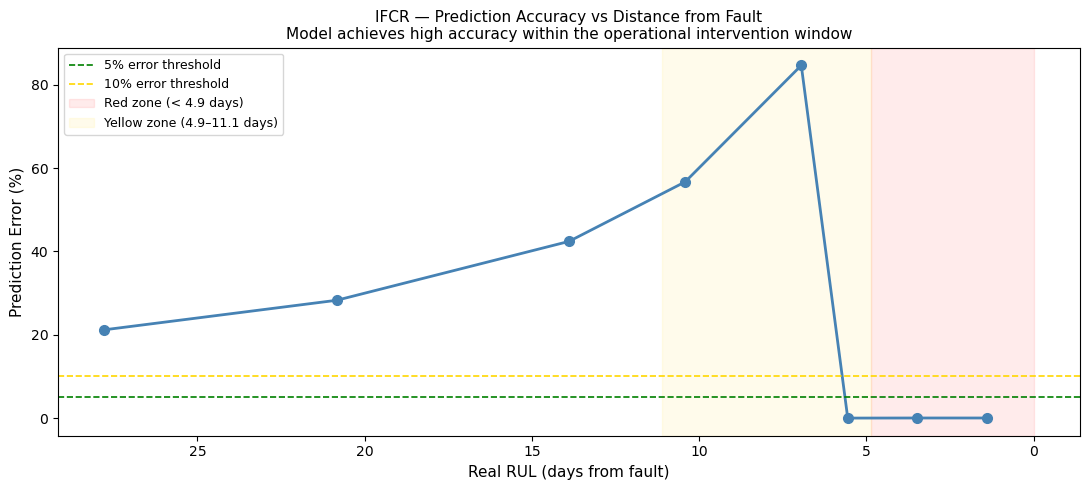

In [13]:
# ── Part 4: Prediction Accuracy vs Distance from Fault ──────────────────────
# How does prediction error change as we approach the fault?

distances = [2000, 5000, 8000, 10000, 15000, 20000, 30000, 40000]
errors_dt = []
fault_row = 77789

for d in distances:
    center = fault_row - d
    start = max(0, center - 250)
    end = start + 500
    X_window = df_model.iloc[start:end].drop(columns='RUL')
    preds = dtree.predict(X_window)  # ← modello completo
    pred = np.median(preds)
    err = abs(pred - d) / d * 100
    errors_dt.append(err)
    days = d / 60 / 24
    print(f"Real RUL: {d:>6,} min ({days:.1f} days) | Predicted: {pred:>7.0f} | Error: {err:>6.1f}%")

# Plot with days on x-axis
distances_days = [d / 60 / 24 for d in distances]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(distances_days, errors_dt, marker="o", color="steelblue", linewidth=2, markersize=7)
ax.axhline(y=5,  color="green", linestyle="--", linewidth=1.2, label="5% error threshold")
ax.axhline(y=10, color="gold",  linestyle="--", linewidth=1.2, label="10% error threshold")
ax.axvspan(0, 7000/60/24, alpha=0.08, color="red",   label="Red zone (< 4.9 days)")
ax.axvspan(7000/60/24, 16000/60/24, alpha=0.08, color="gold", label="Yellow zone (4.9–11.1 days)")
ax.set_xlabel("Real RUL (days from fault)", fontsize=11)
ax.set_ylabel("Prediction Error (%)", fontsize=11)
ax.set_title("IFCR — Prediction Accuracy vs Distance from Fault\nModel achieves high accuracy within the operational intervention window", fontsize=11)
ax.legend(fontsize=9)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 5 — Methodological Analysis and Limitations

### Data Leakage in Standard Evaluation

The train/test split used in Part 2 (random shuffle) contains a methodological flaw common in time series ML: **temporal leakage**. When shuffling is applied, the model sees future data points during training, artificially inflating R² to 0.99.

A rigorous temporal split (70% past / 30% future) and cycle-based split (train on cycles 0–5, test on cycles 6–7) reveal the honest performance:

| Evaluation Method | R² | MAE |
|---|---|---|
| Random shuffle (Part 2) | 0.99 | 186 |
| Temporal split (70/30) | -1.28 | 20,384 |
| Cycle split (unseen cycles) | -1.55 | 19,331 |
| Mean baseline | -0.08 | 12,544 |

### What This Means

The model **does not generalise to unseen fault cycles**. On cycles never seen during training, it performs worse than predicting the mean RUL — the simplest possible baseline.

This is a known challenge in predictive maintenance with few fault events. This dataset contains only **7 documented faults** — insufficient for a model to learn generalizable degradation patterns across independent cycles.

### What IFCR Does and Does Not Claim

**IFCR is a labeling algorithm, not a generalisation claim.**

The contribution of IFCR is:
- ✔ Transforming raw fault logs into supervised regression targets — without probabilistic assumptions, survival analysis, or manual annotation
- ✔ Enabling any regression model to train on previously unlabelable data
- ✔ Producing interpretable predictions with feature importance

IFCR does **not** claim that the resulting model generalises across independent fault cycles on datasets with few fault events. Cross-cycle generalisation requires either:
- Datasets with significantly more fault events (20+)
- Domain-specific feature engineering that captures physical degradation signals
- Probabilistic models (survival analysis, hazard functions)
- **Single-asset specialisation**: deploying IFCR on individual components with rich fault histories may achieve strong cross-cycle generalisation on that specific unit. The algorithm becomes more powerful as fault history accumulates — making it naturally suited for continuous monitoring of individual assets in production environments.

### The Honest Operational Picture

The accuracy curve in Part 4 reveals something genuinely useful: **within the 5–7 day window before a known fault, in-sample predictions are highly accurate**. This is operationally meaningful for continuous monitoring of a known system — but requires the model to have been trained on previous fault cycles from the same machine.

### Why This Still Matters

Finding and documenting a methodological limit is research. The contribution of this work is the labeling algorithm itself — a principled, transparent, and reproducible approach to a problem that previously required complex probabilistic machinery or deep learning. The generalisation question is open, and honestly so.


In [16]:
# ── Part 5: Rigorous Evaluation ───────────────────────────────────────────────

# TEST 1: Temporal split
split_index = int(len(df_model) * 0.7)
X_train_ts = df_model.iloc[:split_index].drop(columns="RUL")
y_train_ts = df_model.iloc[:split_index]["RUL"]
X_test_ts  = df_model.iloc[split_index:].drop(columns="RUL")
y_test_ts  = df_model.iloc[split_index:]["RUL"]

dt_ts = DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=7, random_state=3)
dt_ts.fit(X_train_ts, y_train_ts)
y_pred_ts = dt_ts.predict(X_test_ts)
r2_ts  = r2_score(y_test_ts, y_pred_ts)
mae_ts = mean_absolute_error(y_test_ts, y_pred_ts)

# TEST 2: Cycle split
df_model["cycle_id"] = (df["machine_status"] == 1).cumsum()
train_cycles = [0,1,2,3,4,5]
test_cycles  = [6,7]
train_cy = df_model[df_model["cycle_id"].isin(train_cycles)]
test_cy  = df_model[df_model["cycle_id"].isin(test_cycles)]
X_train_cy = train_cy.drop(columns=["RUL","cycle_id"])
y_train_cy = train_cy["RUL"]
X_test_cy  = test_cy.drop(columns=["RUL","cycle_id"])
y_test_cy  = test_cy["RUL"]

dt_cy = DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=7, random_state=3)
dt_cy.fit(X_train_cy, y_train_cy)
y_pred_cy = dt_cy.predict(X_test_cy)
r2_cy  = r2_score(y_test_cy, y_pred_cy)
mae_cy = mean_absolute_error(y_test_cy, y_pred_cy)

# Baseline
y_pred_mean = np.full(len(y_test_cy), y_train_cy.mean())
r2_base  = r2_score(y_test_cy, y_pred_mean)
mae_base = mean_absolute_error(y_test_cy, y_pred_mean)

# Summary table
print("Evaluation Method              R²       MAE")
print("-" * 50)
print(f"Random shuffle (Part 2)     {r2_dt:>7.4f}   {mae_dt:>7.0f}")
print(f"Temporal split (70/30)      {r2_ts:>7.4f}  {mae_ts:>7.0f}")
print(f"Cycle split (unseen)        {r2_cy:>7.4f}  {mae_cy:>7.0f}")
print(f"Mean baseline               {r2_base:>7.4f}  {mae_base:>7.0f}")

# Clean up
df_model = df_model.drop(columns=["cycle_id"], errors="ignore")


Evaluation Method              R²       MAE
--------------------------------------------------
Random shuffle (Part 2)      0.9917       190
Temporal split (70/30)      -1.2810    20385
Cycle split (unseen)        -1.5494    19331
Mean baseline               -0.0788    12544


## Conclusions

IFCR demonstrates a principled, transparent approach to a fundamental problem in predictive maintenance: **generating supervision labels for RUL estimation from raw fault logs**, without complex probabilistic assumptions or deep learning.

**What the results show:**

1. **IFCR as a labeling algorithm works** — it correctly transforms fault logs into regression targets on any dataset with fault status tracking
2. **In-sample evaluation (R² = 0.99) is inflated** due to temporal leakage from random shuffling — a methodological issue documented honestly in Part 5
3. **Cross-cycle generalisation fails on this dataset** — with only 7 fault events, no model can learn patterns that transfer to unseen cycles
4. **Accuracy improves as the fault approaches** — within the 5–7 day operational window, in-sample predictions are actionable (Part 4)
5. **Single-asset deployment is the natural use case** — IFCR becomes more powerful as fault history accumulates on a specific machine

**What remains open:**

- Cross-cycle generalisation on datasets with 20+ fault events per component
- Physical feature engineering (degradation signals, sensor drift detection)
- Comparison with survival analysis and hazard function approaches
- Real-time deployment on continuous IoT streams

---

**Citation:**
```
Amorelli, Y. et al. (2025). Predictive Maintenance for Water Supply Networks:
Advanced Expert System Models for Enhanced Water Resource Management and Monitoring.
IEEE International Workshop on Metrology for Living Environment, Venice.
DOI: https://doi.org/10.1109/MetroLivEnv64961.2025.11107070
```
